In [1]:
!pip install shap

   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ---------------------------------------- 556.1/556.1 kB 6.3 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   -- ------------------------------------- 2.4/38.1 MB 11.2 MB/s eta 0:00:04
   ---- ----------------------------------- 4.2/38.1 MB 11.4 MB/s eta 0:00:03
   ----- ---------------------------------- 5.0/38.1 MB 7.7 MB/s eta 0:00:05
   ----- ---------------------------------- 5.5/38.1 MB 6.8 MB/s eta 0:00:05
   ------ --------------------------------- 6.0/38.1 MB 5.9 MB/s eta 0:00:06
   ------- -------------------------------- 6.8/38.1 MB 5.4 MB/s eta 0:00:06
   ------- -------------------------------- 7.6/38.1 MB 5.0 MB/s eta 0:00:07
   -------- ------------------------------- 8.4/38.1 MB 4.9 MB/s eta 0:00:07
   --------- ------------------------------ 8.9/38.1 MB 4.7 MB/s eta 0:00:07
   --------- ------------------------------ 9.4/38.1 MB 4.4 MB/s eta 0:00:07
   -------

Precisión del modelo (Accuracy): 0.80

--- 1. GRÁFICO GENERAL (Summary Plot) ---


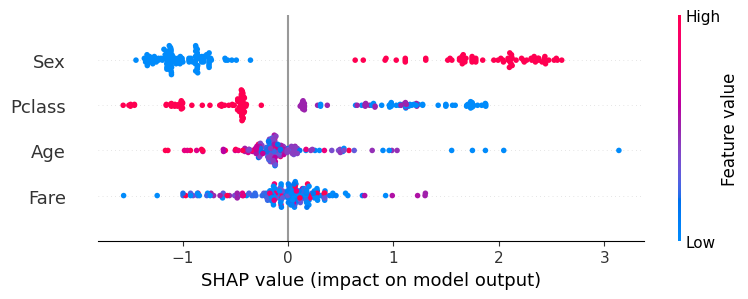


--- 2. EJEMPLO 1 (Pasajero 0) ---


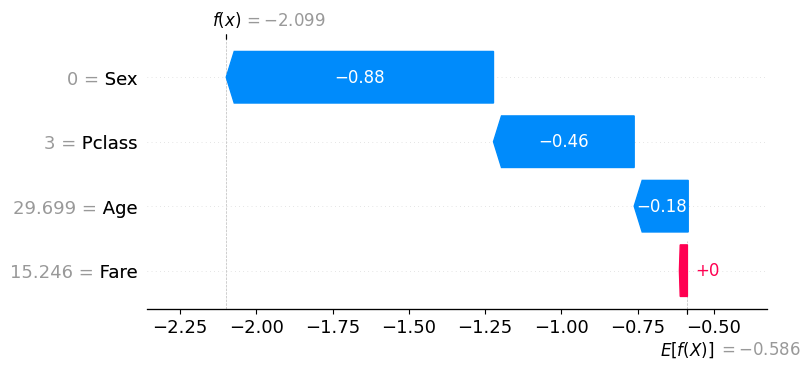


--- 2. EJEMPLO 2 (Pasajero 1) ---


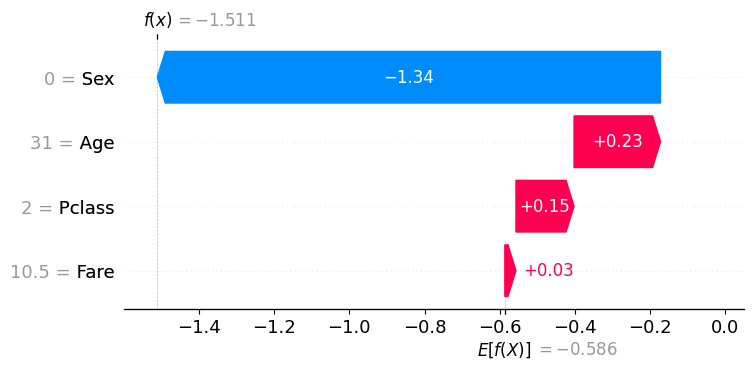


--- 2. EJEMPLO 3 (Pasajero 2) ---


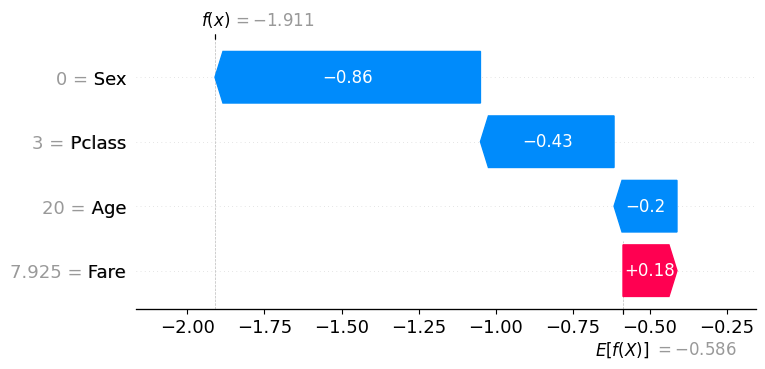

In [2]:
# 1. Importar librerías
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import shap
import matplotlib.pyplot as plt

# 2. Cargar el dataset del Titanic
# Usamos el CSV original y estándar para asegurar que funcione sin tener que descargar nada extra
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
data = pd.read_csv(url)

# Preprocesamiento rápido para que el modelo funcione
# Seleccionamos las columnas más relevantes y numéricas
cols_to_use = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare']
df = data[cols_to_use].copy()

# Rellenar edades vacías con la media para evitar errores
df['Age'] = df['Age'].fillna(df['Age'].mean())

# Convertir 'Sex' a número (0 = male/hombre, 1 = female/mujer)
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

# 3. Separar variables y target
X = df.drop(columns=['Survived'])
y = df['Survived']

# 4. Dividir datos en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Entrenar CLASIFICADOR
# Usamos GradientBoostingClassifier porque funciona excelente con SHAP para clasificaciones binarias
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

# 6. Evaluar brevemente
y_pred = model.predict(X_test)
print(f"Precisión del modelo (Accuracy): {accuracy_score(y_test, y_pred):.2f}\n")

# 7. Usar SHAP para explicar el modelo
# Para modelos de árboles de decisión/boosting, usamos Explainer genérico (usará TreeExplainer)
explainer = shap.Explainer(model)
shap_values = explainer(X_test)

# 8. Gráfico de resumen (Plot general)
print("--- 1. GRÁFICO GENERAL (Summary Plot) ---")
shap.summary_plot(shap_values, X_test)

# 9. Plot de 3 ejemplos (Waterfall)
print("\n--- 2. EJEMPLO 1 (Pasajero 0) ---")
shap.plots.waterfall(shap_values[0])

print("\n--- 2. EJEMPLO 2 (Pasajero 1) ---")
shap.plots.waterfall(shap_values[1])

print("\n--- 2. EJEMPLO 3 (Pasajero 2) ---")
shap.plots.waterfall(shap_values[2])